# ZotVision — CNN-ViT Hybrid Classifier
**EfficientNet-B4 + Google ViT** · 4-class firefighter hazard detection  
Classes: `null` · `hazard` · `person` · `both`

Runs a hyperparameter sweep, auto-selects the best config, and saves everything to a unique Google Drive folder.

## 1 · Install dependencies


In [1]:
!pip install -q efficientnet_pytorch transformers seaborn scikit-learn kagglehub


## 2 · Paths


In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

# ── Kaggle API credentials ──
# Get from kaggle.com → Settings → API → Create New Token
os.environ["KAGGLE_USERNAME"] = "vinscent"  # your Kaggle username
os.environ["KAGGLE_KEY"]      = "your_api_key" # paste your key

# ── Download dataset directly to Colab local disk ──
import kagglehub
dataset_path = kagglehub.dataset_download("vinscent/zotvision-dataset")
print(f"Dataset downloaded to: {dataset_path}")

# ── Paths ──
IMAGES_DIR  = os.path.join(dataset_path, "ZotVision_dataset", "ZotVision_dataset")
LABELS_FILE = os.path.join(dataset_path, "filtered_labels.json")
RESULTS_DIR = "/content/results"
GDRIVE_SAVE = "/content/drive/MyDrive/ZotVision/results"  # where to save permanently

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(GDRIVE_SAVE, exist_ok=True)

print(f"Images : {IMAGES_DIR}")
print(f"Labels : {LABELS_FILE}")
print(f"Images exist: {os.path.isdir(IMAGES_DIR)}")
print(f"Labels exist: {os.path.isfile(LABELS_FILE)}")


## 3 · Imports & config


In [ ]:
import hashlib, json, os, random, shutil, time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from efficientnet_pytorch import EfficientNet
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTModel, ViTConfig

NUM_CLASSES = 3
LABEL_MAP   = {'null': 0, 'hazard': 1, 'person': 2}
ID_TO_LABEL = {0: 'null', 1: 'hazard', 2: 'person'}
CLASS_NAMES = [ID_TO_LABEL[i] for i in range(NUM_CLASSES)]

IMG_SIZE = 224
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

## 4 · Dataset


In [7]:
def ensure_dataset():
    missing = []
    if not os.path.isdir(IMAGES_DIR):  missing.append(IMAGES_DIR)
    if not os.path.isfile(LABELS_FILE): missing.append(LABELS_FILE)
    if missing:
        raise FileNotFoundError("Not found: " + str(missing))
    print("[INFO] Dataset ready.")

ensure_dataset()


[INFO] Dataset ready.


## 5 · Dataset classes


In [ ]:
class CustomDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples, self.transform = samples, transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224))
        if self.transform: img = self.transform(img)
        return img, label


def load_samples(labels_file=LABELS_FILE, images_dir=IMAGES_DIR):
    with open(labels_file) as f:
        data = json.load(f)
    samples = []
    for entry in data["labels"]:
        label_name = entry["label"]
        if label_name not in LABEL_MAP: continue
        p = os.path.join(images_dir, entry["file"])
        if os.path.exists(p): samples.append((p, LABEL_MAP[label_name]))
    return samples


def get_transforms(train):
    if train:
        return transforms.Compose([
            transforms.RandomResizedCrop(IMG_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.2),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])


all_samples = load_samples()
random.seed(42)
random.shuffle(all_samples)
split = int(0.8 * len(all_samples))
train_samples, val_samples = all_samples[:split], all_samples[split:]
print(f"Total: {len(all_samples)}  |  Train: {len(train_samples)}  |  Val: {len(val_samples)}")

from collections import Counter
label_counts = Counter(label for _, label in all_samples)
print("\nClass distribution:")
for label_id in sorted(label_counts):
    print(f"  {ID_TO_LABEL[label_id]:8s}: {label_counts[label_id]:5d}  ({100*label_counts[label_id]/len(all_samples):.1f}%)")

Model - CNN

In [ ]:
#CNN only
class CNNOnly(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.cnn = EfficientNet.from_pretrained('efficientnet-b4')
        in_features = self.cnn._fc.in_features
        self.cnn._fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        return self.cnn(x)


Model ViT

In [10]:
class ViTOnly(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        from transformers import ViTForImageClassification
        self.vit = ViTForImageClassification.from_pretrained(
            'google/vit-base-patch16-224',
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )
    def forward(self, x):
        return self.vit(x).logits


## 6 · Model — CNN-ViT Hybrid

In [ ]:
class CNNViTHybrid(nn.Module):
    """
    EfficientNet-B4 feature extractor → patch projection → CLS token
    → positional embedding → Google ViT encoder → MLP classifier
    """
    def __init__(self, efficientnet_variant='efficientnet-b4', vit_hidden_size=768,
                 vit_num_layers=6, vit_num_heads=12, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.cnn = EfficientNet.from_pretrained(efficientnet_variant)
        cnn_ch = self.cnn._conv_head.out_channels
        self.cnn._avg_pooling = self.cnn._dropout = self.cnn._fc = nn.Identity()
        for name, p in self.cnn.named_parameters():
            if not any(k in name for k in ['_blocks.28','_blocks.29','_blocks.30','_blocks.31','_conv_head']):
                p.requires_grad = False

        self.patch_proj = nn.Conv2d(cnn_ch, vit_hidden_size, kernel_size=1)
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, vit_hidden_size))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.pos_embed  = nn.Parameter(torch.zeros(1, 50, vit_hidden_size))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.vit_hidden_size = vit_hidden_size

        self.vit_encoder = ViTModel(ViTConfig(
            hidden_size=vit_hidden_size, num_hidden_layers=vit_num_layers,
            num_attention_heads=vit_num_heads, intermediate_size=vit_hidden_size*4,
            hidden_dropout_prob=dropout, attention_probs_dropout_prob=dropout,
            image_size=IMG_SIZE, patch_size=16, num_channels=3,
        ))
        self.classifier = nn.Sequential(
            nn.LayerNorm(vit_hidden_size), nn.Linear(vit_hidden_size, 256),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(256, num_classes),
        )

    def forward(self, x):
        B    = x.size(0)
        feat = self.patch_proj(self.cnn.extract_features(x))
        N    = feat.shape[2] * feat.shape[3]
        feat = feat.flatten(2).transpose(1, 2)
        tokens = torch.cat([self.cls_token.expand(B,-1,-1), feat], dim=1)
        if self.pos_embed.size(1) != N+1:
            pos = nn.functional.interpolate(
                self.pos_embed.transpose(1,2), size=N+1, mode='linear', align_corners=False
            ).transpose(1,2)
        else:
            pos = self.pos_embed
        tokens = tokens + pos
        out = self.vit_encoder.encoder(tokens)
        cls = self.vit_encoder.layernorm(out.last_hidden_state)[:, 0, :]
        return self.classifier(cls)

## 7 · Training utilities

In [ ]:
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """Focal loss with per-class alpha weights. Downweights easy majority-class examples."""
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.register_buffer('alpha', alpha)
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward(); optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate_per_class(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        probs = torch.softmax(model(imgs.to(device)), dim=1)
        all_preds.extend(probs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


print('Training utilities defined.')

## 8 · Per-label accuracy & confusion heatmap

In [12]:
def compute_per_class_accuracy(preds, labels, class_names=CLASS_NAMES):
    report_dict = classification_report(labels, preds, target_names=class_names, digits=4, output_dict=True)
    print(classification_report(labels, preds, target_names=class_names, digits=4))
    per_class_acc = {cls: round(report_dict[cls]['recall'], 4) for cls in class_names}
    df = pd.DataFrame([
        {'Label': cls, 'Accuracy': per_class_acc[cls],
         'Precision': round(report_dict[cls]['precision'], 4),
         'F1-score':  round(report_dict[cls]['f1-score'],  4),
         'Support':   int(report_dict[cls]['support'])}
        for cls in class_names
    ]).set_index('Label')
    display(df.style.background_gradient(cmap='YlGn', subset=['Accuracy', 'F1-score']))
    return per_class_acc


def plot_confusion_heatmap(preds, labels, class_names=CLASS_NAMES, save_path=None):
    cm      = confusion_matrix(labels, preds, labels=range(len(class_names)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, fmt, cmap, title in [
        (axes[0], cm,      'd',   'Blues',   'Confusion Matrix (counts)'),
        (axes[1], cm_norm, '.2f', 'Oranges', 'Confusion Matrix (normalized)'),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f'Heatmap saved → {save_path}')
    plt.show()

print('Metrics helpers defined.')

Metrics helpers defined.


## 9 · Save results


In [13]:
import shutil, hashlib, time

def save_to_drive(results_dir=RESULTS_DIR, gdrive_save=GDRIVE_SAVE):
    import hashlib, time
    h = hashlib.sha1(str(time.time()).encode()).hexdigest()[:6]
    dest = os.path.join(gdrive_save, f"run_{h}")
    shutil.copytree(results_dir, dest)
    print(f"[Drive] Saved to: {dest}")
    for f in sorted(os.listdir(dest)):
        size = os.path.getsize(os.path.join(dest, f))
        print(f"  {f}  ({size//1024} KB)")
    return dest

print("Drive save helper defined.")


## 10 · Hyperparameter grid
8 configs covering a range of learning rates, dropout levels, weight decay values, and batch sizes.
Edit or extend this cell freely — the sweep will pick the best automatically.

In [14]:
HYPERPARAM_GRID = [
    # id  description
    # 0   baseline
    {'lr': 3e-4, 'dropout': 0.10, 'weight_decay': 1e-3, 'batch_size': 8, 'num_epochs': 20},
    # 1   lower lr — finer updates
    {'lr': 1e-4, 'dropout': 0.20, 'weight_decay': 1e-4, 'batch_size': 16, 'num_epochs': 20},
    # 2   higher lr + larger batch
    {'lr': 5e-4, 'dropout': 0.30, 'weight_decay': 1e-3, 'batch_size': 32, 'num_epochs': 20},
    # 3   small batch — noisy gradients act as regularizer
    {'lr': 3e-4, 'dropout': 0.20, 'weight_decay': 1e-2, 'batch_size':  8, 'num_epochs': 20},
    # 4   aggressive lr — fast convergence
    {'lr': 1e-3, 'dropout': 0.10, 'weight_decay': 1e-4, 'batch_size': 16, 'num_epochs': 15},
    # 5   sweet-spot: moderate lr + light decay
    {'lr': 2e-4, 'dropout': 0.15, 'weight_decay': 5e-4, 'batch_size': 16, 'num_epochs': 20},
    # 6   large batch + low dropout — less noise
    {'lr': 5e-4, 'dropout': 0.10, 'weight_decay': 1e-3, 'batch_size': 32, 'num_epochs': 20},
    # 7   conservative — very low lr, longer run
    {'lr': 5e-5, 'dropout': 0.20, 'weight_decay': 1e-4, 'batch_size': 16, 'num_epochs': 25},
]

# Preview the grid
df_grid = pd.DataFrame(HYPERPARAM_GRID)
df_grid.index.name = 'id'
display(df_grid)

,lr,dropout,weight_decay,batch_size,num_epochs
id,,,,,
0,0.00030,0.10,0.0010,8,20
1,0.00010,0.20,0.0001,16,20
2,0.00050,0.30,0.0010,32,20
3,0.00030,0.20,0.0100,8,20
4,0.00100,0.10,0.0001,16,15
5,0.00020,0.15,0.0005,16,20
6,0.00050,0.10,0.0010,32,20
7,0.00005,0.20,0.0001,16,25


## 11 · Training loop
Each config runs with **early stopping** (patience = 4 epochs). Best checkpoint per run is kept.

In [ ]:
os.makedirs(RESULTS_DIR, exist_ok=True)

EARLY_STOP_PATIENCE = 4   # ← tweak if desired


def train_config(config, train_samples, val_samples, run_id, results_dir=RESULTS_DIR):
    print(f"\n{'='*62}")
    print(f'  Run {run_id} | {config}')
    print(f"{'='*62}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    train_loader = DataLoader(
        CustomDataset(train_samples, get_transforms(True)),
        batch_size=config['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
    val_loader = DataLoader(
        CustomDataset(val_samples, get_transforms(False)),
        batch_size=config['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

    #model = CNNViTHybrid(dropout=config['dropout']).to(DEVICE)
    #model = CNNOnly(dropout=config['dropout']).to(DEVICE)
    model = ViTOnly(dropout=config['dropout']).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['num_epochs'])
    # null upweighted to counter imbalance; hazard and person at baseline
    criterion = FocalLoss(
        alpha=torch.tensor([1.0, 1.3, 1.0]).to(DEVICE)
    )

    weights_path = os.path.join(results_dir, f'model_run{run_id}.pth')
    best_val_acc = 0.0
    no_improve   = 0
    history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, config['num_epochs'] + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        v_loss, v_acc = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        flag = ''
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            no_improve   = 0
            torch.save(model.state_dict(), weights_path)
            flag = '  ← best'
        else:
            no_improve += 1

        print(f'  Epoch {epoch:03d}/{config["num_epochs"]} | '
              f'Train {t_loss:.4f}/{t_acc:.4f}  Val {v_loss:.4f}/{v_acc:.4f}{flag}')

        if no_improve >= EARLY_STOP_PATIENCE:
            print(f'  [Early stop] No improvement for {EARLY_STOP_PATIENCE} epochs.')
            break

    model.load_state_dict(torch.load(weights_path, weights_only=True))
    preds, lbls = evaluate_per_class(model, val_loader, DEVICE)
    per_class_acc = compute_per_class_accuracy(preds, lbls)
    plot_confusion_heatmap(preds, lbls,
                           save_path=os.path.join(results_dir, f'heatmap_run{run_id}.png'))

    epochs_run = len(history['val_acc'])
    return {
        'run_id':        run_id,
        'config':        config,
        'best_val_acc':  best_val_acc,
        'per_class_acc': per_class_acc,
        'epochs_run':    epochs_run,
        'history':       history,
    }

In [16]:
from tqdm import tqdm

all_results = []
for i, cfg in enumerate(tqdm(HYPERPARAM_GRID, desc="Configs")):
    result = train_config(cfg, train_samples, val_samples, run_id=i)
    all_results.append(result)

print(f'\nAll {len(all_results)} configs done.')

Configs:   0%|          | 0/8 [00:00<?, ?it/s]


  Run 0 | {'lr': 0.0003, 'dropout': 0.1, 'weight_decay': 0.001, 'batch_size': 8, 'num_epochs': 20}


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoch 001/20 | Train 1.1599/0.6066  Val 1.0588/0.6661  ← best
  Epoch 002/20 | Train 1.0476/0.6810  Val 1.0552/0.6726  ← best
  Epoch 003/20 | Train 1.0134/0.7031  Val 0.9812/0.7169  ← best
  Epoch 004/20 | Train 0.9998/0.7067  Val 0.9906/0.7091
  Epoch 005/20 | Train 0.9910/0.7062  Val 0.9525/0.7239  ← best
  Epoch 006/20 | Train 0.9695/0.7265  Val 0.9208/0.7414  ← best
  Epoch 007/20 | Train 0.9590/0.7238  Val 0.9540/0.7384
  Epoch 008/20 | Train 0.9449/0.7317  Val 0.9025/0.7534  ← best
  Epoch 009/20 | Train 0.9316/0.7379  Val 0.9071/0.7446
  Epoch 010/20 | Train 0.9199/0.7478  Val 0.8868/0.7606  ← best
  Epoch 011/20 | Train 0.9094/0.7535  Val 0.8699/0.7673  ← best
  Epoch 012/20 | Train 0.8896/0.7637  Val 0.8600/0.7534
  Epoch 013/20 | Train 0.8847/0.7628  Val 0.8614/0.7652
  Epoch 014/20 | Train 0.8685/0.7739  Val 0.8327/0.7855  ← best
  Epoch 015/20 | Train 0.8536/0.7806  Val 0.8262/0.7847
  Epoch 016/20 | Train 0.8457/0.7861  Val 0.8196/0.7839
  Epoch 017/20 | Train 0.8312/0.

Configs:   0%|          | 0/8 [6:46:27<?, ?it/s]


KeyboardInterrupt: 

## 12 · Select best config
Ranked leaderboard — all configs sorted by validation accuracy. Best weights are promoted to `model_weights.pth`.

In [24]:
ranked = sorted(all_results, key=lambda r: r["best_val_acc"], reverse=True)

rows = []
for rank, r in enumerate(ranked, 1):
    row = {
        "Rank":         rank,
        "Run":          f"run{r['run_id']}",
        "Val Acc":      r["best_val_acc"],
        "Epochs Run":   r["epochs_run"],
        "LR":           r["config"]["lr"],
        "Dropout":      r["config"]["dropout"],
        "Weight Decay": r["config"]["weight_decay"],
        "Batch Size":   r["config"]["batch_size"],
    }
    row.update({f"acc_{k}": v for k, v in r["per_class_acc"].items()})
    rows.append(row)

df_lb = pd.DataFrame(rows).set_index("Rank")
display(
    df_lb.style
        .background_gradient(cmap="YlGn",  subset=["Val Acc"])
        .background_gradient(cmap="Blues", subset=[c for c in df_lb.columns if c.startswith("acc_")])
        .format({"Val Acc": "{:.4f}", **{c: "{:.4f}" for c in df_lb.columns if c.startswith("acc_")}})
)


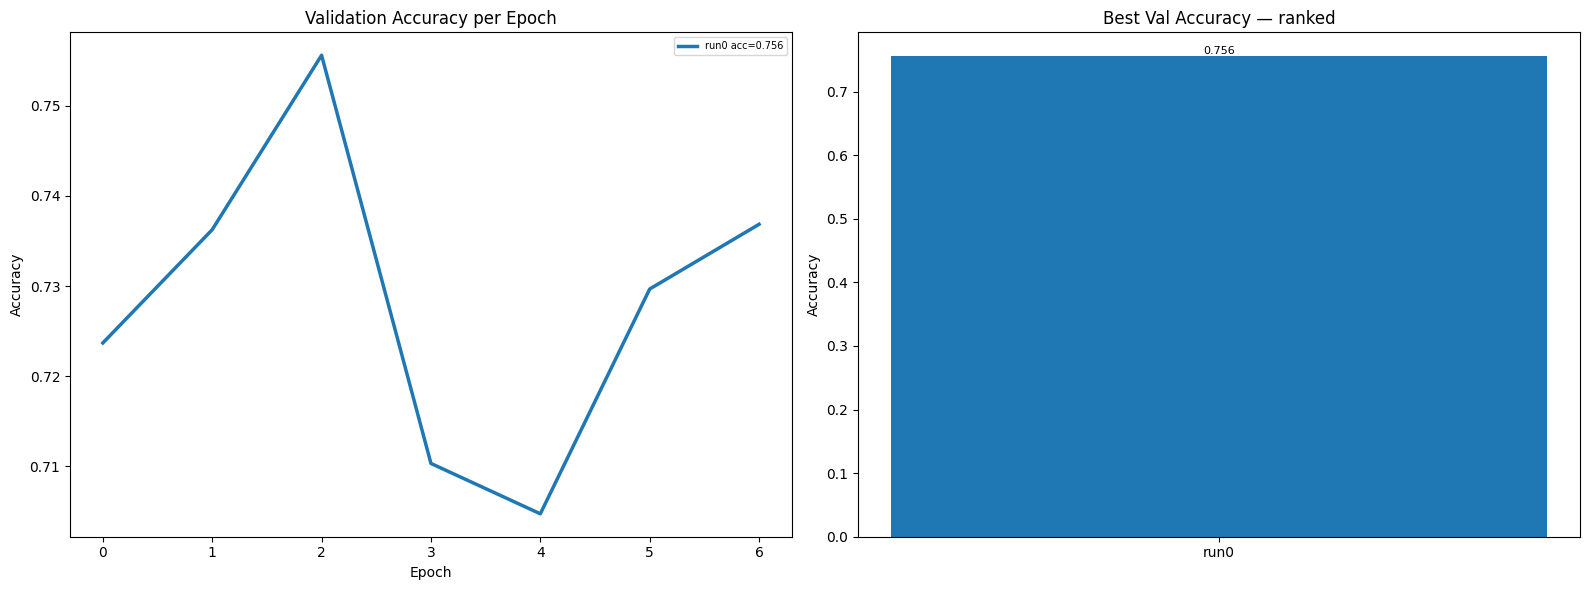

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = sns.color_palette('tab10', len(all_results))
for r, c in zip(ranked, palette):
    lbl = f"run{r['run_id']} acc={r['best_val_acc']:.3f}"
    lw  = 2.5 if r is ranked[0] else 1.0
    axes[0].plot(r['history']['val_acc'], label=lbl, color=c, linewidth=lw)
axes[0].set_title('Validation Accuracy per Epoch'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(fontsize=7)

run_labels = [f"run{r['run_id']}" for r in ranked]
accs       = [r['best_val_acc'] for r in ranked]
colors     = [palette[i] for i in range(len(ranked))]
bars = axes[1].bar(run_labels, accs, color=colors)
axes[1].set_title('Best Val Accuracy — ranked'); axes[1].set_ylabel('Accuracy')
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{acc:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'run_comparison.png'), dpi=150)
plt.show()

IndexError: list index out of range

## 13 · Results


In [ ]:
dest = save_to_drive()
print(f"All results saved to Google Drive: {dest}")


## 14 · Inference on a single image

In [20]:
@torch.no_grad()
def predict(model, image_path, device=DEVICE):
    img = get_transforms(False)(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)
    model.eval()
    return ID_TO_LABEL[model(img).argmax(1).item()]


# Example — load best model and run inference
# best_model = CNNViTHybrid().to(DEVICE)
# best_model.load_state_dict(torch.load(best_dst, weights_only=True))
# print(predict(best_model, '/path/to/image.jpg'))